# Numerical Integration — Complete Walkthrough
This notebook is organized as a step-by-step comparison of deterministic and probabilistic integration methods.

## Learning goals
- Understand **what each method approximates** (plain integral, weighted integral, or expectation under a measure).
- See **when methods agree** and **why they differ** (discretization error, truncation error, stochastic error, model error).
- Build intuition for the practical tradeoffs between speed, accuracy, and assumptions.

## Notebook roadmap
1. Uniform-grid rules (Rectangle, Trapezoid, Simpson)
2. Weighted-node Gaussian quadrature rules (Legendre, Hermite, Laguerre, Chebyshev)
3. Monte Carlo estimators (standard, weighted, recursive)
4. Bayesian Quadrature (GP posterior over the integral)
5. Interpolation + Integration cross-comparison

Throughout the notebook, focus on two questions:
- **What is being integrated?** (original function vs weighted form vs interpolation surrogate)
- **Where does the error come from?** (grid, truncation, randomness, or surrogate bias)


## Section 1 — Density Setup and Uniform-Grid Integration
In this section we define several probability density functions and integrate them with uniform-grid rules.

## Why this section matters
Uniform-grid methods are the most direct baseline for 1D integration:
- simple to understand,
- deterministic,
- good reference point before moving to Monte Carlo or Bayesian methods.

## Test densities used
- Uniform(a,b), Triangular(a,b,c): compact support; true integral over support is exactly 1.
- Normal, Laplace, Cauchy, Exponential: infinite support; we use finite windows for practical computation.

## Important implementation detail
For infinite-domain densities, we integrate on truncated intervals, e.g.:
- Normal: [-6, 6]
- Laplace: [-10, 10]
- Cauchy: [-25, 25]
- Exponential: [0, 10]

This means total error has two components:
- **numerical integration error** on the finite interval,
- **truncation error** from omitted tails.


In [8]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("/Users/I768838/Desktop/Probabilistic-quadrature")))

import numpy as np
import matplotlib.pyplot as plt

from source.functions.function import Function
from source.functions.domain import Domain
from source.functions.interval import Interval
from source.numeric_integration.numeric_integral_factory.numeric_integral_factory import NumericIntegralFactory
from source.numeric_integration.numeric_integration_pattern import NumericIntegrationPattern


factory = NumericIntegralFactory()


def construct_some_probability_density_function() -> list[Function]:
    a, b, c, mu, sigma, lam, b_lap, gamma = 0, 1, 0.5, 0, 1, 1, 1, 1

    uniform_density_function = Function(
        lambda x: 1 / (b - a), 
        Domain(Interval(a, b)), 
        None, "Uniform(a,b)"
    )

    normal_density_function = Function(
        lambda x: (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)), 
        Domain(Interval(float("-inf"), float("inf"))), 
        None, "Normal(mu,sigma)"
    )

    exp_density = Function(
        lambda x: lam * np.exp(-lam * x), 
        Domain(Interval(0.0, float("inf"))), 
        None, "Exp(lambda)"
    )

    laplace_density = Function(
        lambda x: (1 / (2 * b_lap)) * np.exp(-np.abs(x - mu) / b_lap), 
        Domain(Interval(float("-inf"), float("inf"))), 
        None, "Laplace(mu,b)")

    cauchy_density = Function(
        lambda x: (1 / (np.pi * gamma * (1 + ((x - mu) / gamma) ** 2))), 
        Domain(Interval(float("-inf"), float("inf"))), 
        None, "Cauchy(mu,gamma)")

    tri_density = Function(
        lambda x: (2*(x-a)/((b-a)*(c-a)) if a <= x < c else 2*(b-x)/((b-a)*(b-c)) if c <= x <= b else 0.0), 
        Domain(Interval(a, b)), 
        None, "Triangular(a,b,c)")

    return [
        uniform_density_function, normal_density_function,
        exp_density, laplace_density, cauchy_density, tri_density
    ]


def finite_interval_for_density(function: Function) -> Interval:
    if function.name.startswith("Normal"): return Interval(-6, 6)
    if function.name.startswith("Laplace"): return Interval(-10, 10)
    if function.name.startswith("Cauchy"): return Interval(-25, 25)
    if function.name.startswith("Exp"): return Interval(0.0, 10)
    return function.domain.get_interval()


def uniform_grid_integration(function: Function, interval: Interval, point_density: int) -> None:
    x_coordinates = list(np.linspace(interval.get_left_component(), interval.get_right_component(), point_density))

    rectangle_integration_method = factory.create(NumericIntegrationPattern.RECTANGLE, None, function, interval, x_coordinates, point_density - 1)
    simpson_integration_method = factory.create(NumericIntegrationPattern.SIMPSON, None, function, interval, x_coordinates, point_density - 1)
    trapezoid_integration_method = factory.create(NumericIntegrationPattern.TRAPEZOID, None, function, interval, x_coordinates, point_density - 1)

    print(f"\n{function.name} on [{interval.get_left_component()}, {interval.get_right_component()}]")
    print(f"Rectangle : {rectangle_integration_method.integrate():.8f}")
    print(f"Simpson   : {simpson_integration_method.integrate():.8f}")
    print(f"Trapezoid : {trapezoid_integration_method.integrate():.8f}\n")
    

probability_density_functions = construct_some_probability_density_function()
for current_probability_density_function in probability_density_functions:
    interval = finite_interval_for_density(current_probability_density_function)
    uniform_grid_integration(current_probability_density_function, interval, 1000)


Uniform(a,b) on [0.0, 1.0]
Rectangle : 1.00000000
Simpson   : 1.00000000
Trapezoid : 1.00000000


Normal(mu,sigma) on [-6.0, 6.0]
Rectangle : 1.00000000
Simpson   : 1.00000000
Trapezoid : 1.00000000


Exp(lambda) on [0.0, 10.0]
Rectangle : 0.99995043
Simpson   : 0.99995460
Trapezoid : 0.99996295


Laplace(mu,b) on [-10.0, 10.0]
Rectangle : 0.99998800
Simpson   : 0.99997130
Trapezoid : 0.99993790


Cauchy(mu,gamma) on [-25.0, 25.0]
Rectangle : 0.97454879
Simpson   : 0.97454878
Trapezoid : 0.97454876


Triangular(a,b,c) on [0.0, 1.0]
Rectangle : 1.00000100
Simpson   : 1.00000033
Trapezoid : 0.99999900



## Uniform Grid Methods — How to Read the Output
The code prints three approximations on the same interval and node density:
- `Rectangle` (midpoint rule)
- `Trapezoid`
- `Simpson`

## Interpretation logic
1. First compare the value to 1.0 for true PDFs over their full support.
2. If the method is accurate but truncation is aggressive, value can still be biased.
3. If truncation is wide enough, differences between rules reflect discretization quality.

## What to expect
- Simpson should typically be best for smooth functions at equal node count.
- Rectangle/Trapezoid usually improve as `point_density` increases.
- For heavy tails (e.g. Cauchy), widening the interval is often more important than adding many points.

## Practical tuning
- Increase `point_density` to reduce grid error.
- Increase truncation window to reduce tail loss.
- Tune both together; increasing only one may saturate gains.


## Section 2 — Weighted-Node (Gaussian) Quadrature
Here we evaluate Gauss-type quadrature rules.

## Core idea
Gaussian quadrature chooses nodes and weights optimally for a specific orthogonal-polynomial family and weight function.

## Rules used
- Legendre: finite interval, unit weight.
- Hermite: (-inf, inf), weight exp(-x^2).
- Laguerre: [0, inf), weight exp(-x).
- Chebyshev: [-1, 1], weight 1/sqrt(1-x^2).

## Why this section is subtle
Not all reported values are plain area-under-density values:
- Hermite/Laguerre/Chebyshev compute weighted integrals by construction.
- Only Legendre aligns directly with standard finite-interval integration without extra weighting.


In [9]:
def weighted_nodes_integration(function: Function, count_of_nodes: int) -> None:
    interval = function.domain.get_interval()

    left = interval.get_left_component()
    right = interval.get_right_component()
    print(f"\n{function.name} (weighted nodes, n={count_of_nodes})")

    if np.isfinite(left) and np.isfinite(right):
        leg = factory.create(NumericIntegrationPattern.LEGENDRE, None, function, count_of_nodes, interval)
        print(f"Gauss-Legendre : {leg.integrate():.8f}")

        if np.isclose(left, -1.0) and np.isclose(right, 1.0):
            cheb = factory.create(NumericIntegrationPattern.CHEBYSHEV, None, function, count_of_nodes)
            print(f"Gauss-Chebyshev: {cheb.integrate():.8f}")
        else:
            print("Gauss-Chebyshev: skipped (requires interval [-1, 1])")

    if np.isneginf(left) and np.isposinf(right):
        herm = factory.create(NumericIntegrationPattern.HERMITE, None, function, count_of_nodes)
        print(f"Gauss-Hermite  : {herm.integrate():.8f}")

    if np.isclose(left, 0.0) and np.isposinf(right):
        lag = factory.create(NumericIntegrationPattern.LAGUERRE, None, function, count_of_nodes)
        print(f"Gauss-Laguerre : {lag.integrate():.8f}")


for current_probability_density_function in probability_density_functions:
    weighted_nodes_integration(current_probability_density_function, 100)


Uniform(a,b) (weighted nodes, n=100)
Gauss-Legendre : 1.00000000
Gauss-Chebyshev: skipped (requires interval [-1, 1])

Normal(mu,sigma) (weighted nodes, n=100)
Gauss-Hermite  : 0.57735027

Exp(lambda) (weighted nodes, n=100)
Gauss-Laguerre : 0.50000000

Laplace(mu,b) (weighted nodes, n=100)
Gauss-Hermite  : 0.54358070

Cauchy(mu,gamma) (weighted nodes, n=100)
Gauss-Hermite  : 0.42758358

Triangular(a,b,c) (weighted nodes, n=100)
Gauss-Legendre : 0.99991856
Gauss-Chebyshev: skipped (requires interval [-1, 1])


## Weighted-Node Methods — Output Interpretation
Use the following checklist when reading numbers:

1. Confirm domain compatibility
- Legendre requires finite interval.
- Chebyshev is enabled only for [-1, 1] in this notebook.

2. Confirm quantity being computed
- Legendre: approximates standard integral over the interval.
- Hermite/Laguerre/Chebyshev: approximates weighted integral defined by that rule.

3. Compare fairly
- Compare Legendre vs grid-based methods on finite intervals.
- Do not treat Hermite/Laguerre/Chebyshev outputs as "should be 1" unless transformed to matching weighted formulation.

## Accuracy control
- Increasing `count_of_nodes` usually improves accuracy quickly for smooth compatible integrands.
- Mismatch between integrand structure and rule weight can dominate error even with many nodes.


## Section 3 — Monte Carlo Integration
This section estimates integrals via sampling from a uniform measure on a finite interval.

## Estimators used
- `Standard MC`: sample average under the measure.
- `Weighted MC`: importance-style interface (here with constant weights as a control baseline).
- `Recursive MC`: hierarchical subdivision; in this implementation it is aligned to the same expectation semantics.

## Quantity reported in the code
Each estimator first approximates expectation under Uniform[a,b], then values are scaled by `(b-a)` for plain-integral reporting.

## Why this section matters
Monte Carlo introduces stochastic error, unlike deterministic grid/quadrature rules, so repeated runs vary.


In [10]:
from source.numeric_integration.monte_carlo.monte_carlo_factory.monte_carlo_factory import MonteCarloFactory
from source.measures.uniform_box_measure import UniformBoxMeasure
from source.numeric_integration.monte_carlo.monte_carlo_stretegies import MonteCarloIntegrationStrategy
from source.random_variables.continuous_random_variables.uniform import Uniform
from source.functions.measured_function import MeasuredFunction


monte_carlo_method_factory = MonteCarloFactory()


def monte_carlo_integration(function: Function, interval: Interval, n_samples: int = 20000, depth: int = 4) -> None:
    a = interval.get_left_component()
    b = interval.get_right_component()
    if not (np.isfinite(a) and np.isfinite(b)):
        raise ValueError("Monte Carlo demo needs a finite interval.")

    measure = UniformBoxMeasure(np.array([a]), np.array([b]))
    random_variable = Uniform(a, b)
    def eval_function_on_samples(X):
        X = np.atleast_2d(X)
        return np.array([function(x) for x in X[:, 0]])

    mc_function = MeasuredFunction(eval_function_on_samples, measure, input_name=function.name)

    mc_standard = monte_carlo_method_factory.create(
        MonteCarloIntegrationStrategy.STANDARD,
        mc_function, measure, n_samples=n_samples, rv=random_variable
    )
    mc_weighted = monte_carlo_method_factory.create(
        MonteCarloIntegrationStrategy.WEIGHTED,
        mc_function, measure, n_samples=n_samples, rv=random_variable,
        proposal_sampler=lambda n, r: r.sample(n),
        weight_fn=lambda x: np.ones(x.shape[0])
    )
    mc_recursive = monte_carlo_method_factory.create(
        MonteCarloIntegrationStrategy.RECURSIVE,
        mc_function, measure, n_samples=n_samples, rv=random_variable, depth=depth
    )

    volume = b - a
    std_est = mc_standard.integrate() * volume
    wgt_est = mc_weighted.integrate() * volume
    rec_est = mc_recursive.integrate() * volume

    std_err = mc_standard.stderr * volume if mc_standard.stderr else None
    wgt_err = mc_weighted.stderr * volume if mc_weighted.stderr else None

    print(f"\n{function.name} MC on [{a}, {b}] (n={n_samples})")
    print(f"MC standard : {std_est:.8f}" + (f"  stderr≈{std_err:.2e}" if std_err else ""))
    print(f"MC weighted : {wgt_est:.8f}" + (f"  stderr≈{wgt_err:.2e}" if wgt_err else ""))
    print(f"MC recursive: {rec_est:.8f}")


for current_probability_density_function in probability_density_functions:
    interval = finite_interval_for_density(current_probability_density_function)
    monte_carlo_integration(current_probability_density_function, interval, n_samples=20000, depth=5)


Uniform(a,b) MC on [0.0, 1.0] (n=20000)
MC standard : 1.00000000
MC weighted : 1.00000000
MC recursive: 1.00000000

Normal(mu,sigma) MC on [-6.0, 6.0] (n=20000)
MC standard : 1.02138174  stderr≈1.10e-02
MC weighted : 1.01891107  stderr≈1.10e-02
MC recursive: 1.00136514

Exp(lambda) MC on [0.0, 10.0] (n=20000)
MC standard : 0.99041189  stderr≈1.40e-02
MC weighted : 1.02409718  stderr≈1.43e-02
MC recursive: 0.99625608

Laplace(mu,b) MC on [-10.0, 10.0] (n=20000)
MC standard : 1.00901655  stderr≈1.42e-02
MC weighted : 0.98613744  stderr≈1.40e-02
MC recursive: 1.00312633

Cauchy(mu,gamma) MC on [-25.0, 25.0] (n=20000)
MC standard : 1.00228937  stderr≈1.90e-02
MC weighted : 0.96417562  stderr≈1.85e-02
MC recursive: 0.97403728

Triangular(a,b,c) MC on [0.0, 1.0] (n=20000)
MC standard : 0.99485293  stderr≈4.08e-03
MC weighted : 0.99449905  stderr≈4.06e-03
MC recursive: 1.00017979


## Monte Carlo — How to Read the Output
- `MC standard`: baseline stochastic estimator.
- `MC weighted`: should be close to standard in this notebook because weights are constant.
- `MC recursive`: same target quantity, different allocation strategy.
- `stderr`: uncertainty estimate for standard/weighted estimators.

## Error decomposition
Monte Carlo output can differ from reference because of:
- sampling variance ~ O(1/sqrt(N)),
- truncation bias if interval is finite approximation of infinite support.

## Practical guidance
- Increase `n_samples` to reduce variance.
- Repeat runs to measure stability.
- If means are consistently biased, expand interval before further increasing sample count.


## Section 4 — Bayesian Quadrature
In Bayesian Quadrature (BQ), the integrand is modeled as a Gaussian Process (GP), and the integral is treated as a random variable.

## Pipeline in this notebook
1. Sample training inputs from the chosen measure.
2. Evaluate function values at these inputs.
3. Fit GP with selected kernel (RBF or Matern 3/2).
4. Compute posterior mean and posterior variance of the integral.

## Why BQ is different
BQ returns both:
- a point estimate (posterior mean),
- a calibrated uncertainty proxy (posterior variance),
unlike deterministic quadrature which returns only a point estimate.


In [11]:
from source.kernels.rbf_kernel import RBFKernel
from source.kernels.matern32_kernel import Matern32Kernel
from source.measures.gaussian_measure import GaussianMeasure
from source.measures.measure import Measure


def construct_some_test_functions() -> list[Function]:
    domain = Domain(Interval(float("-inf"), float("inf")))
    return [
        Function(lambda x: x**2, domain, None, "x^2"),
        Function(lambda x: np.sin(x), domain, None, "sin(x)"),
        Function(lambda x: np.cos(x), domain, None, "cos(x)"),
        Function(lambda x: np.exp(-x**2), domain, None, "exp(-x^2)"),
        Function(lambda x: x**4, domain, None, "x^4"),
        Function(lambda x: np.tanh(x), domain, None, "tanh(x)"),
        Function(lambda x: np.sin(2*x) + 0.5*np.cos(3*x), domain, None, "sin(2x)+0.5cos(3x)")
    ]


def bayesian_quadrature_integration(function: Function, measure: Measure, count_of_nodes: int = 20, want_rbf: bool = True,
    lengthscale: float = 1.0, variance: float = 1.0, noise: float = 0.0, jitter: float = 1e-8) -> None:
    X = measure.sample(count_of_nodes)
    y = np.array([function(x[0]) for x in X])
    if want_rbf:
        kernel = RBFKernel(lengthscale=lengthscale, variance=variance)
    else:
        kernel = Matern32Kernel(lengthscale=lengthscale, variance=variance)

    bayesian_quadratue = factory.create(
        NumericIntegrationPattern.BAYESIAN, None,
        function, measure, kernel, X, y, noise=noise, jitter=jitter
    )

    estimate = bayesian_quadratue.integrate()
    variance_post = bayesian_quadratue.variance
    print(f"\n{function.name} (BQ, n={count_of_nodes})")
    print(f"Estimate: {estimate:.6f}")
    print(f"Posterior variance: {variance_post:.6e}")


measure = GaussianMeasure(mean=np.array([0.0]), cov=np.array([[1.0]]))
functions = construct_some_test_functions()

for current_test_function in functions:
    bayesian_quadrature_integration(current_test_function, measure, count_of_nodes=20, want_rbf=True)
    bayesian_quadrature_integration(current_test_function, measure, count_of_nodes=20, want_rbf=False)



x^2 (BQ, n=20)
Estimate: 0.923445
Posterior variance: 1.030736e-04

x^2 (BQ, n=20)
Estimate: 0.698658
Posterior variance: 7.480381e-03

sin(x) (BQ, n=20)
Estimate: 0.000370
Posterior variance: 5.163004e-05

sin(x) (BQ, n=20)
Estimate: -0.010263
Posterior variance: 0.000000e+00

cos(x) (BQ, n=20)
Estimate: 0.606977
Posterior variance: 1.319167e-06

cos(x) (BQ, n=20)
Estimate: 0.621254
Posterior variance: 1.605532e-03

exp(-x^2) (BQ, n=20)
Estimate: 0.577820
Posterior variance: 6.011160e-06

exp(-x^2) (BQ, n=20)
Estimate: 0.583059
Posterior variance: 0.000000e+00

x^4 (BQ, n=20)
Estimate: 2.500942
Posterior variance: 2.126362e-05

x^4 (BQ, n=20)
Estimate: 1.895478
Posterior variance: 0.000000e+00

tanh(x) (BQ, n=20)
Estimate: -0.009728
Posterior variance: 1.093586e-04

tanh(x) (BQ, n=20)
Estimate: -0.002598
Posterior variance: 0.000000e+00

sin(2x)+0.5cos(3x) (BQ, n=20)
Estimate: 0.003573
Posterior variance: 3.747277e-07

sin(2x)+0.5cos(3x) (BQ, n=20)
Estimate: 0.011919
Posterior varian

## Bayesian Quadrature — Output Interpretation
- `Estimate`: posterior mean of the integral.
- `Posterior variance`: model uncertainty after conditioning on observed points.

## What controls performance
- Kernel choice and hyperparameters (lengthscale, variance).
- Number and location of sampled points.
- Quality of kernel-integral term approximation inside the implementation.

## Notes specific to this project
- For generic kernel/measure combinations, some kernel integral terms are estimated via Monte Carlo, introducing additional approximation noise.
- Lower posterior variance is desirable, but should always be checked against actual integration error.


## Section 5 — Interpolation + Integration Comparison
This section directly compares two pipelines on identical finite intervals:
1. Integrate the **original function**.
2. Interpolate first (Lagrange/Newton/Hermite), then integrate the interpolant.

## Why this comparison is useful
It separates two effects:
- integration-method error,
- interpolation-surrogate error.

## What is reported
- Absolute error vs a high-accuracy `scipy.integrate.quad` reference.
- Table by integration method and surrogate type.
- Heatmap of `log10(abs error)` for fast visual ranking.

## Key interpretation question
If integrated interpolants are much worse than direct integration, the bottleneck is likely surrogate quality (node placement/order), not the quadrature rule itself.



sin(x) on [-3.142, 3.142] | reference=0.0000000000 | nodes=11
Method                True err    Lagrange err    Newton err   Hermite err
Rectangle            2.984e-16       3.074e-16     6.663e-16     5.762e-16
Trapezoid            2.312e-16       6.656e-16     1.880e-15     7.063e-17
Simpson              8.905e-16       3.045e-16     5.441e-16     1.140e-15
Gauss-Legendre       7.741e-17       4.844e-16     2.529e-15     5.965e-16
MC standard          9.155e-03       5.729e-02     1.572e-02     1.068e-02


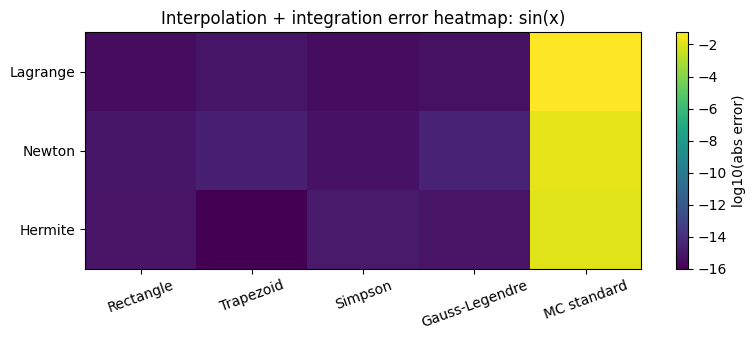


exp(-x^2) on [-3.000, 3.000] | reference=1.7724146965 | nodes=11
Method                True err    Lagrange err    Newton err   Hermite err
Rectangle            1.388e-08       1.292e-01     1.292e-01     8.600e-04
Trapezoid            2.776e-08       1.290e-01     1.290e-01     8.599e-04
Simpson              7.825e-13       1.291e-01     1.291e-01     8.599e-04
Gauss-Legendre       6.619e-13       1.291e-01     1.291e-01     8.599e-04
MC standard          4.762e-03       1.522e-01     1.380e-01     1.230e-02


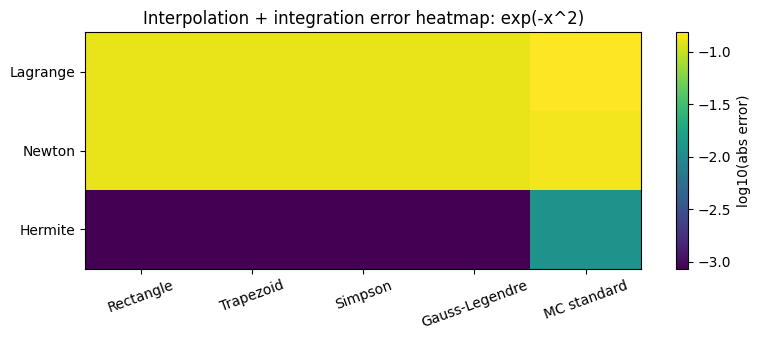


1/(1+25x^2) on [-1.000, 1.000] | reference=0.5493603068 | nodes=11
Method                True err    Lagrange err    Newton err   Hermite err
Rectangle            1.541e-07       3.855e-01     3.855e-01     7.081e-01
Trapezoid            3.082e-07       3.850e-01     3.850e-01     7.081e-01
Simpson              3.422e-13       3.853e-01     3.853e-01     7.081e-01
Gauss-Legendre       3.632e-04       3.853e-01     3.853e-01     7.081e-01
MC standard          2.327e-03       3.858e-01     3.709e-01     7.005e-01


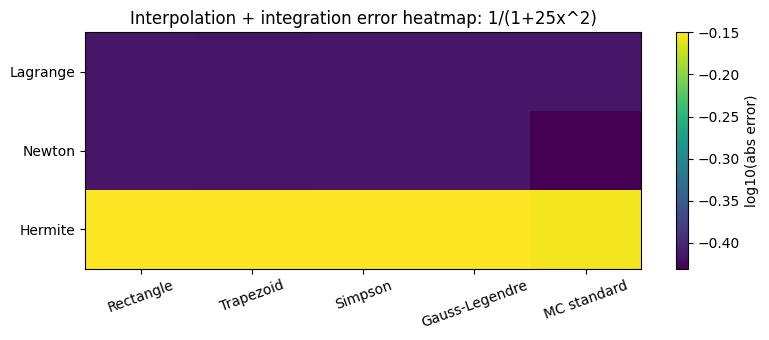

In [12]:
from scipy.integrate import quad

import numpy as np
import matplotlib.pyplot as plt

from source.functions.function import Function
from source.functions.domain import Domain
from source.functions.interval import Interval
from source.functions.measured_function import MeasuredFunction
from source.measures.uniform_box_measure import UniformBoxMeasure
from source.random_variables.continuous_random_variables.uniform import Uniform
from source.numeric_integration.numeric_integral_factory.numeric_integral_factory import NumericIntegralFactory
from source.numeric_integration.numeric_integration_pattern import NumericIntegrationPattern
from source.functions.polynomial_interpolations.interpolation_pattern import InterpolationPattern
from source.functions.polynomial_interpolations.polynomial_interpolation_factory.polynomial_interpolation_factory import PolynomialInterpolationFactory
from source.numeric_integration.monte_carlo.monte_carlo_factory.monte_carlo_factory import MonteCarloFactory
from source.numeric_integration.monte_carlo.monte_carlo_stretegies import MonteCarloIntegrationStrategy

integration_factory = NumericIntegralFactory()
poly_factory = PolynomialInterpolationFactory()
mc_factory = MonteCarloFactory()


def integrate_callable(model_callable, interval: Interval, sub_intervals: int = 400, gauss_nodes: int = 20, mc_samples: int = 12000):
    a = interval.get_left_component()
    b = interval.get_right_component()
    x_coords = list(np.linspace(a, b, sub_intervals + 1))

    estimates = {
        "Rectangle": integration_factory.create(NumericIntegrationPattern.RECTANGLE, None, model_callable, interval, x_coords, sub_intervals).integrate(),
        "Trapezoid": integration_factory.create(NumericIntegrationPattern.TRAPEZOID, None, model_callable, interval, x_coords, sub_intervals).integrate(),
        "Simpson": integration_factory.create(NumericIntegrationPattern.SIMPSON, None, model_callable, interval, x_coords, sub_intervals).integrate(),
        "Gauss-Legendre": integration_factory.create(NumericIntegrationPattern.LEGENDRE, None, model_callable, gauss_nodes, interval).integrate(),
    }

    measure = UniformBoxMeasure(np.array([a]), np.array([b]))
    rv = Uniform(a, b)

    def evaluate_on_samples(X, g=model_callable):
        X = np.atleast_2d(X)
        return np.array([g(float(x)) for x in X[:, 0]])

    measured = MeasuredFunction(evaluate_on_samples, measure, input_name=getattr(model_callable, "name", "interp"))
    mc = mc_factory.create(
        MonteCarloIntegrationStrategy.STANDARD,
        measured, measure, n_samples=mc_samples, rv=rv
    )
    estimates["MC standard"] = mc.integrate() * (b - a)
    return estimates


cases = [
    ("sin(x)", lambda x: np.sin(x), Interval(-np.pi, np.pi)),
    ("exp(-x^2)", lambda x: np.exp(-x**2), Interval(-3.0, 3.0)),
    ("1/(1+25x^2)", lambda x: 1.0 / (1.0 + 25.0 * x**2), Interval(-1.0, 1.0)),
]

methods = ["Rectangle", "Trapezoid", "Simpson", "Gauss-Legendre", "MC standard"]
node_count = 11
h = 1e-4

for name, raw_fn, interval in cases:
    a = interval.get_left_component()
    b = interval.get_right_component()

    true_fn = Function(raw_fn, Domain(interval), None, name)
    hermite_fn = Function(raw_fn, Domain(Interval(a - h, b + h)), None, f"{name} (Hermite helper)")

    nodes = list(np.linspace(a, b, node_count))
    values = [true_fn(x) for x in nodes]

    lagrange_poly = poly_factory.create(InterpolationPattern.LAGRANGE, nodes, values)
    newton_poly = poly_factory.create(InterpolationPattern.NEWTON, nodes, values)
    hermite_poly = poly_factory.create(InterpolationPattern.HERMIT, nodes, values, hermite_fn, h)

    reference, _ = quad(raw_fn, a, b)

    pipelines = {
        "True": true_fn,
        "Lagrange": lagrange_poly,
        "Newton": newton_poly,
        "Hermite": hermite_poly,
    }

    estimates = {label: integrate_callable(model, interval) for label, model in pipelines.items()}

    print(f"\n{name} on [{a:.3f}, {b:.3f}] | reference={reference:.10f} | nodes={node_count}")
    print("Method".ljust(16) + "True err".rjust(14) + "Lagrange err".rjust(16) + "Newton err".rjust(14) + "Hermite err".rjust(14))
    for method in methods:
        row = [
            abs(estimates["True"][method] - reference),
            abs(estimates["Lagrange"][method] - reference),
            abs(estimates["Newton"][method] - reference),
            abs(estimates["Hermite"][method] - reference),
        ]
        print(
            method.ljust(16)
            + f"{row[0]:14.3e}{row[1]:16.3e}{row[2]:14.3e}{row[3]:14.3e}"
        )

    heatmap = np.array([
        [abs(estimates["Lagrange"][m] - reference) for m in methods],
        [abs(estimates["Newton"][m] - reference) for m in methods],
        [abs(estimates["Hermite"][m] - reference) for m in methods],
    ])

    plt.figure(figsize=(8, 3.5))
    im = plt.imshow(np.log10(np.maximum(heatmap, 1e-16)), aspect="auto", cmap="viridis")
    plt.colorbar(im, label="log10(abs error)")
    plt.xticks(range(len(methods)), methods, rotation=20)
    plt.yticks([0, 1, 2], ["Lagrange", "Newton", "Hermite"])
    plt.title(f"Interpolation + integration error heatmap: {name}")
    plt.tight_layout()
    plt.show()


## Final Takeaways (Notebook-Level)
- Start with a deterministic baseline (Simpson or Legendre on finite intervals).
- For infinite domains, treat truncation choice as a first-class parameter.
- Use Monte Carlo when dimension/geometry makes deterministic rules expensive.
- Use Bayesian Quadrature when uncertainty quantification is important and function evaluations are limited.
- Validate interpolation-based acceleration carefully: surrogate bias can dominate total error.

## Suggested next experiments
- Add Chebyshev nodes in interpolation stage and compare heatmaps.
- Run multiple MC seeds and plot confidence intervals.
- Compare active point selection in BQ against random sampling under equal evaluation budget.
